# Resume Analyzer EDA\n
\n
Initial notebook for exploratory data analysis.

1️⃣ Import Libraries


In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import re
from collections import Counter

sns.set(style="whitegrid")

2️⃣ Load Dataset

In [2]:
df = pd.read_csv("../data/raw/UpdatedResumeDataSet.csv")

df.head()

,Category,Resume
0,Data Science,Skills * Programming Languages: Python (pandas...
1,Data Science,Education Details \r\nMay 2013 to May 2017 B.E...
2,Data Science,"Areas of Interest Deep Learning, Control Syste..."
3,Data Science,Skills â¢ R â¢ Python â¢ SAP HANA â¢ Table...
4,Data Science,"Education Details \r\n MCA YMCAUST, Faridab..."


3️⃣ Basic Info

In [3]:
print("Shape:", df.shape)
print("\nColumns:", df.columns)

df.info()

Shape: (962, 2)

Columns: Index(['Category', 'Resume'], dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 962 entries, 0 to 961
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Category  962 non-null    object
 1   Resume    962 non-null    object
dtypes: object(2)
memory usage: 15.2+ KB


4️⃣ Check Missing Values

In [4]:
df.isnull().sum()

Category    0
Resume      0
dtype: int64

5️⃣ Duplicate Check


In [5]:
print("Duplicate rows:", df.duplicated().sum())

df = df.drop_duplicates()

Duplicate rows: 796


6️⃣ Category Distribution


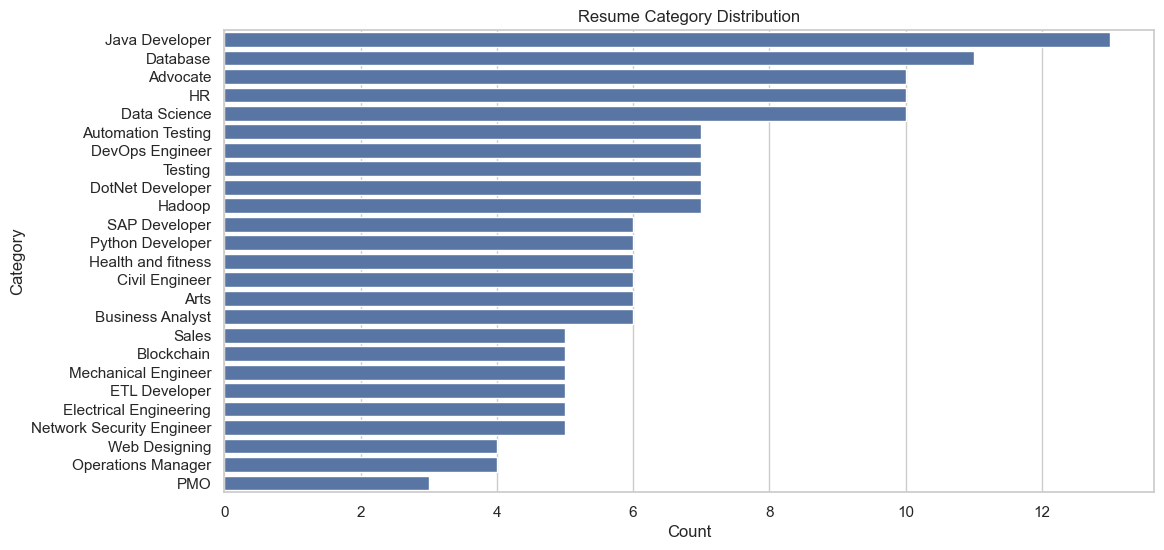

In [6]:
plt.figure(figsize=(12,6))
sns.countplot(y=df['Category'], order=df['Category'].value_counts().index)
plt.title("Resume Category Distribution")
plt.xlabel("Count")
plt.ylabel("Category")
plt.show()

7️⃣ Class Imbalance Check

In [7]:
df['Category'].value_counts(normalize=True) * 100

Category
Java Developer               7.831325
Database                     6.626506
Advocate                     6.024096
HR                           6.024096
Data Science                 6.024096
Automation Testing           4.216867
DevOps Engineer              4.216867
Testing                      4.216867
DotNet Developer             4.216867
Hadoop                       4.216867
SAP Developer                3.614458
Python Developer             3.614458
Health and fitness           3.614458
Civil Engineer               3.614458
Arts                         3.614458
Business Analyst             3.614458
Sales                        3.012048
Blockchain                   3.012048
Mechanical Engineer          3.012048
ETL Developer                3.012048
Electrical Engineering       3.012048
Network Security Engineer    3.012048
Web Designing                2.409639
Operations Manager           2.409639
PMO                          1.807229
Name: proportion, dtype: float64

8️⃣ Text Length Analysis

In [8]:
df['char_length'] = df['Resume'].apply(len)
df['word_count'] = df['Resume'].apply(lambda x: len(x.split()))

df[['char_length', 'word_count']].describe()

,char_length,word_count
count,166.000000,166.000000
mean,2980.114458,424.771084
std,2646.110439,380.604490
min,142.000000,19.000000
25%,1036.000000,161.250000
50%,2361.000000,330.000000
75%,3886.500000,571.500000
max,14816.000000,2209.000000


9️⃣ Length Distribution


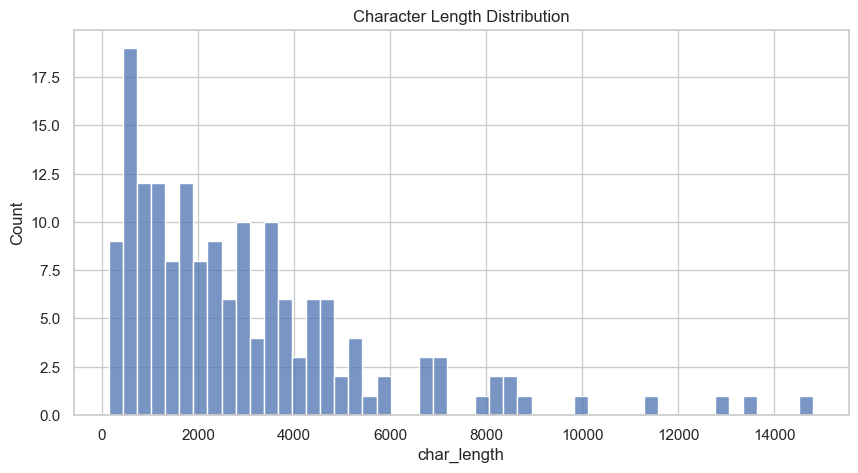

In [9]:
plt.figure(figsize=(10,5))
sns.histplot(df['char_length'], bins=50)
plt.title("Character Length Distribution")
plt.show()

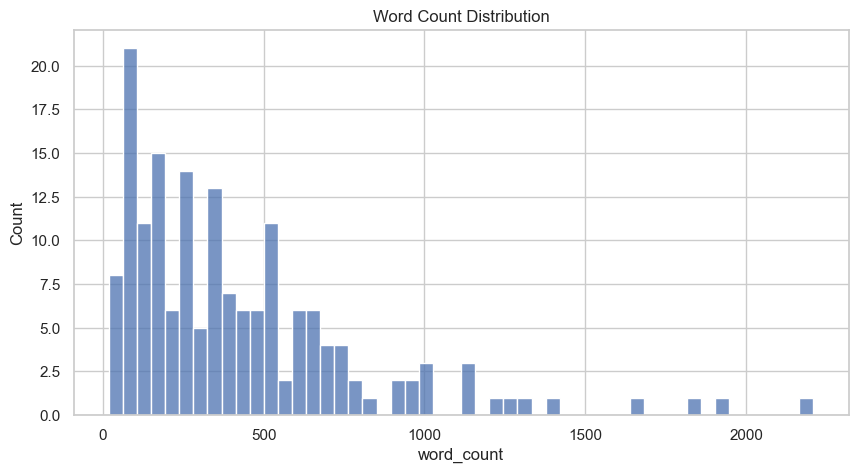

In [10]:
plt.figure(figsize=(10,5))
sns.histplot(df['word_count'], bins=50)
plt.title("Word Count Distribution")
plt.show()

🔟 Category vs Resume Length


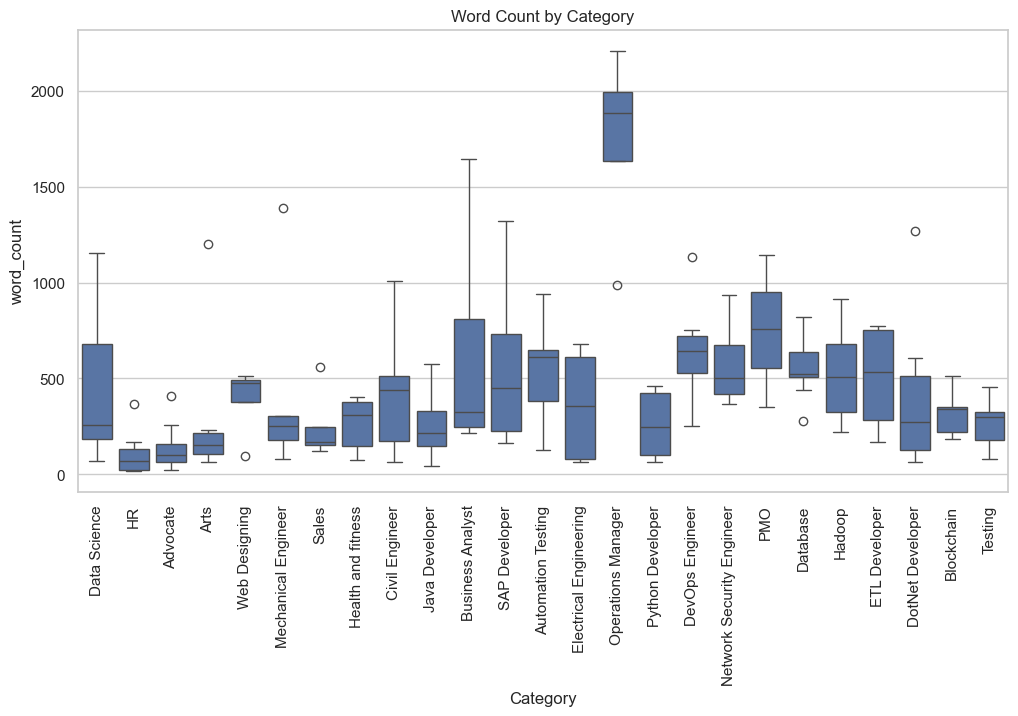

In [11]:
plt.figure(figsize=(12,6))
sns.boxplot(x='Category', y='word_count', data=df)
plt.xticks(rotation=90)
plt.title("Word Count by Category")
plt.show()

1️⃣1️⃣ Text Cleaning (Basic)

In [12]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'\W', ' ', text)
    text = re.sub(r'\d', ' ', text)
    return text

df['cleaned'] = df['Resume'].apply(clean_text)

1️⃣2️⃣ Most Common Words


In [13]:
all_text = " ".join(df['cleaned'])

words = all_text.split()

common_words = Counter(words).most_common(20)

common_words

[('and', 2693),
 ('â', 2669),
 ('the', 1708),
 ('of', 1411),
 ('to', 1234),
 ('in', 902),
 ('for', 809),
 ('exprience', 616),
 ('company', 602),
 ('with', 580),
 ('project', 542),
 ('description', 540),
 ('details', 531),
 ('months', 525),
 ('on', 486),
 ('a', 398),
 ('data', 390),
 ('as', 385),
 ('management', 316),
 ('database', 278)]

1️⃣3️⃣ Plot Top Words

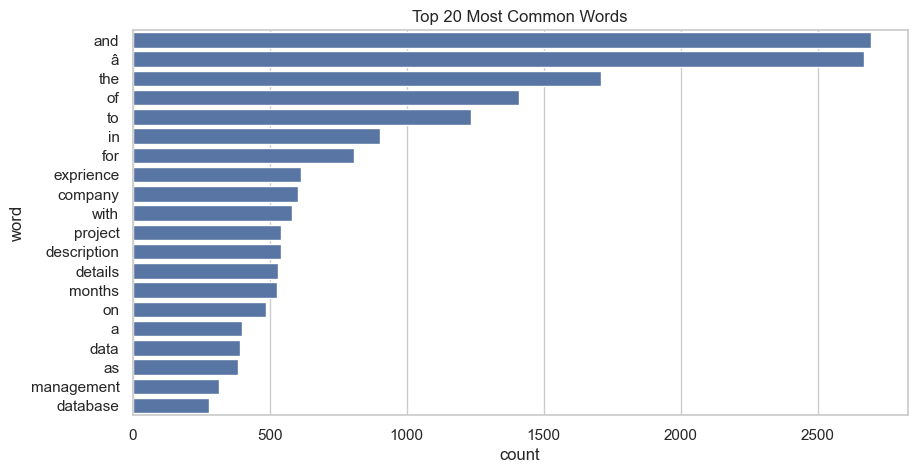

In [14]:
words_df = pd.DataFrame(common_words, columns=["word", "count"])

plt.figure(figsize=(10,5))
sns.barplot(x="count", y="word", data=words_df)
plt.title("Top 20 Most Common Words")
plt.show()

1️⃣3️⃣ Plot Top Words

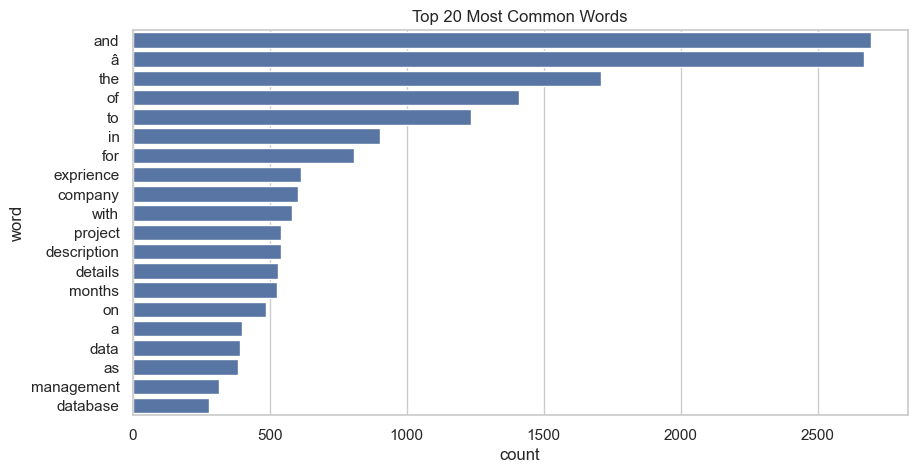

In [15]:
words_df = pd.DataFrame(common_words, columns=["word", "count"])

plt.figure(figsize=(10,5))
sns.barplot(x="count", y="word", data=words_df)
plt.title("Top 20 Most Common Words")
plt.show()

1️⃣4️⃣ Category-wise Word Analysis

In [16]:
category = "Data Science"

text = " ".join(df[df['Category'] == category]['cleaned'])

words = text.split()

Counter(words).most_common(15)

[('and', 154),
 ('â', 112),
 ('the', 108),
 ('data', 99),
 ('to', 85),
 ('of', 80),
 ('exprience', 62),
 ('in', 62),
 ('months', 60),
 ('for', 53),
 ('learning', 51),
 ('python', 47),
 ('science', 42),
 ('year', 42),
 ('than', 40)]

1️⃣5️⃣ Unique Words Per Resume

In [17]:
df['unique_words'] = df['cleaned'].apply(lambda x: len(set(x.split())))

df[['unique_words']].describe()

,unique_words
count,166.000000
mean,184.825301
std,131.255567
min,13.000000
25%,84.250000
50%,160.500000
75%,248.500000
max,735.000000


1️⃣6️⃣ Correlation Analysis

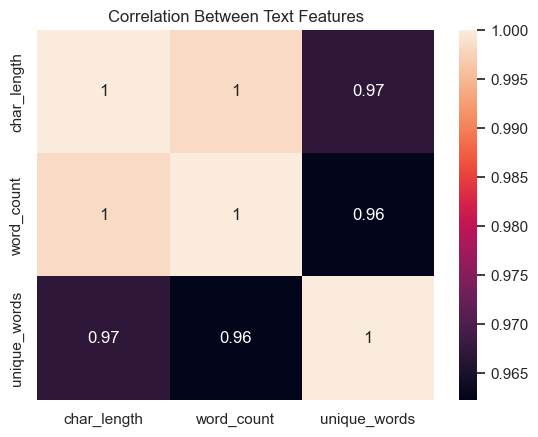

In [18]:
sns.heatmap(df[['char_length','word_count','unique_words']].corr(), annot=True)
plt.title("Correlation Between Text Features")
plt.show()

1️⃣7️⃣ Category Encoding (for ML)

In [19]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['Category_encoded'] = le.fit_transform(df['Category'])

df[['Category', 'Category_encoded']].head()

,Category,Category_encoded
0,Data Science,6
1,Data Science,6
2,Data Science,6
3,Data Science,6
4,Data Science,6


1️⃣8️⃣ TF-IDF Preview (Feature Engineering Insight)

In [20]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=20)

X = tfidf.fit_transform(df['cleaned'])

print(tfidf.get_feature_names_out())

['and' 'as' 'company' 'data' 'database' 'description' 'details'
 'exprience' 'for' 'in' 'is' 'management' 'months' 'of' 'on' 'project'
 'team' 'the' 'to' 'with']


1️⃣9️⃣ Save Cleaned Dataset

In [21]:
df.to_csv("../data/processed/cleaned_resume.csv", index=False)